# Amazon Food Review Sentiment Analysis

This notebook contains the full ML workflow for the project: loading data, EDA, preprocessing, imbalance-aware multiclass model training, evaluation, learning curve analysis, and artifact export for the Flask API.

The task is multiclass sentiment classification from Amazon food review text:

- `Score` 1-2 -> `Negatif` / label `0`
- `Score` 3 -> `Netral` / label `1`
- `Score` 4-5 -> `Positif` / label `2`

## Setup

In [1]:
from datetime import datetime, timezone
import html
import io
import json
import re
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import learning_curve, train_test_split
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import label_binarize

RANDOM_STATE = 42
DATASET_PATH = Path("Reviews.csv")
MODEL_OUTPUT_PATH = Path("sentiment_pipeline.pkl")
METADATA_OUTPUT_PATH = Path("model_metadata.json")
LEARNING_CURVE_MAX_ROWS = 60000

LABEL_NAMES = {"0": "Negatif", "1": "Netral", "2": "Positif"}
LABEL_ORDER = [0, 1, 2]
TARGET_NAMES = [LABEL_NAMES[str(label)] for label in LABEL_ORDER]

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)

## Load Dataset

In [2]:
df = pd.read_csv(DATASET_PATH)
print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
df.head()

Dataset shape: 568,454 rows x 10 columns


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The pr...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this w...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all","This is a confection that has been around a few centuries. It is a light, pillowy citrus gelatin with nuts - in thi..."
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient in Robitussin I believe I have found it. I got this in addition to the...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wide assortment of yummy taffy. Delivery was very quick. If your a taff...


## Non-Graphical EDA

This section checks schema, missing values, duplicate text, score distribution, candidate class distribution, and basic text-length statistics before any model training.

In [3]:
print("Columns:")
print(df.columns.tolist())

buffer = io.StringIO()
df.info(buf=buffer)
print(buffer.getvalue())

Columns:
['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']
<class 'pandas.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   Id                      568454 non-null  int64
 1   ProductId               568454 non-null  str  
 2   UserId                  568454 non-null  str  
 3   ProfileName             568428 non-null  str  
 4   HelpfulnessNumerator    568454 non-null  int64
 5   HelpfulnessDenominator  568454 non-null  int64
 6   Score                   568454 non-null  int64
 7   Time                    568454 non-null  int64
 8   Summary                 568427 non-null  str  
 9   Text                    568454 non-null  str  
dtypes: int64(5), str(5)
memory usage: 43.4 MB



In [4]:
missing_summary = (
    df.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_percent=lambda x: (x["missing_count"] / len(df) * 100).round(4))
)
missing_summary

,missing_count,missing_percent
Id,0,0.0000
ProductId,0,0.0000
UserId,0,0.0000
ProfileName,26,0.0046
HelpfulnessNumerator,0,0.0000
HelpfulnessDenominator,0,0.0000
Score,0,0.0000
Time,0,0.0000
Summary,27,0.0047
Text,0,0.0000


In [5]:
score_distribution = (
    df["Score"]
    .value_counts()
    .sort_index()
    .rename_axis("Score")
    .reset_index(name="count")
)
score_distribution["percent"] = (score_distribution["count"] / len(df) * 100).round(2)
score_distribution

,Score,count,percent
0,1,52268,9.19
1,2,29769,5.24
2,3,42640,7.50
3,4,80655,14.19
4,5,363122,63.88


In [6]:
def score_to_multiclass_label(score):
    if score <= 2:
        return 0
    if score == 3:
        return 1
    return 2

eda_multiclass = df.copy()
eda_multiclass["label"] = eda_multiclass["Score"].apply(score_to_multiclass_label)
eda_multiclass["sentiment"] = eda_multiclass["label"].map({0: "Negatif", 1: "Netral", 2: "Positif"})

class_distribution = (
    eda_multiclass["sentiment"]
    .value_counts()
    .reindex(["Negatif", "Netral", "Positif"])
    .rename_axis("sentiment")
    .reset_index(name="count")
)
class_distribution["percent"] = (class_distribution["count"] / class_distribution["count"].sum() * 100).round(2)
class_distribution

,sentiment,count,percent
0,Negatif,82037,14.43
1,Netral,42640,7.50
2,Positif,443777,78.07


In [7]:
duplicate_text_rows = int(df.duplicated(subset=["Text"]).sum())
duplicate_text_percent = duplicate_text_rows / len(df) * 100
conflicting_duplicate_groups = int(df.groupby("Text")["Score"].nunique().gt(1).sum())

print(f"Duplicate Text rows: {duplicate_text_rows:,} ({duplicate_text_percent:.2f}%)")
print(f"Duplicate Text groups with conflicting Score values: {conflicting_duplicate_groups:,}")
print(f"Unique ProductId values: {df['ProductId'].nunique():,}")
print(f"Unique UserId values: {df['UserId'].nunique():,}")

Duplicate Text rows: 174,875 (30.76%)
Duplicate Text groups with conflicting Score values: 95
Unique ProductId values: 74,258
Unique UserId values: 256,059


In [8]:
eda_df = df.copy()
eda_df["Text"] = eda_df["Text"].fillna("").astype(str)
eda_df["text_char_len"] = eda_df["Text"].str.len()
eda_df["text_word_count"] = eda_df["Text"].str.split().str.len()

eda_df[["text_char_len", "text_word_count"]].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2)

,text_char_len,text_word_count
count,568454.00,568454.00
mean,436.22,80.26
std,445.34,79.46
min,12.00,3.00
25%,179.00,33.00
50%,302.00,56.00
75%,527.00,98.00
90%,877.00,161.00
95%,1202.00,218.00
99%,2166.00,388.00


## Graphical EDA

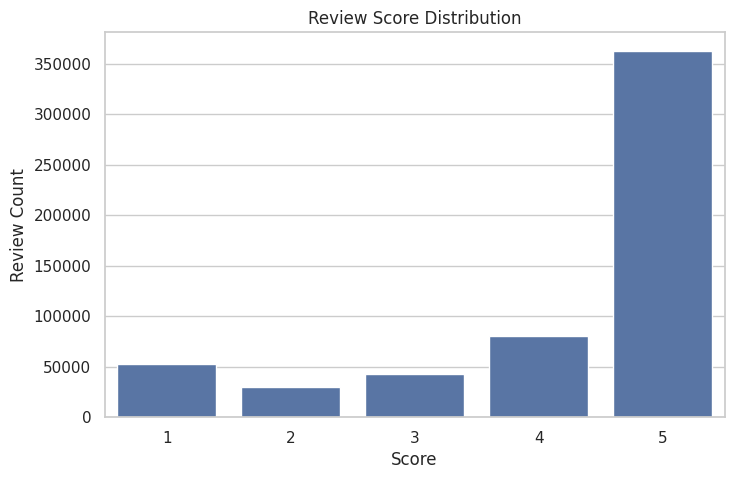

In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Score", order=sorted(df["Score"].dropna().unique()))
plt.title("Review Score Distribution")
plt.xlabel("Score")
plt.ylabel("Review Count")
plt.show()

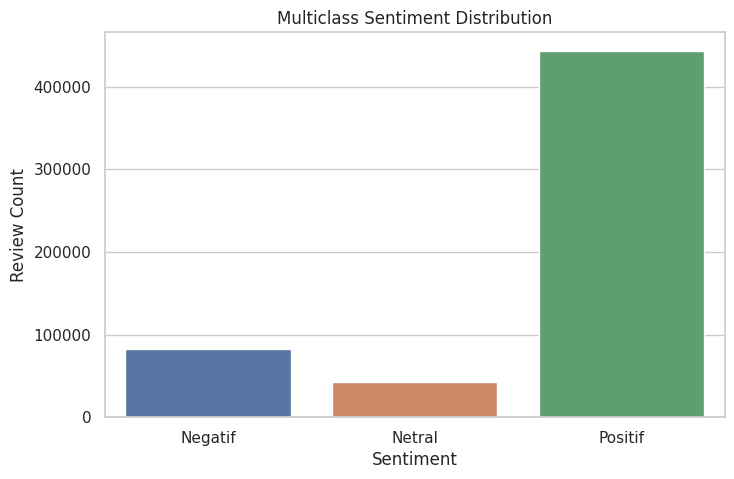

In [10]:
plt.figure(figsize=(8, 5))
sns.barplot(data=class_distribution, x="sentiment", y="count", hue="sentiment", legend=False)
plt.title("Multiclass Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Review Count")
plt.show()

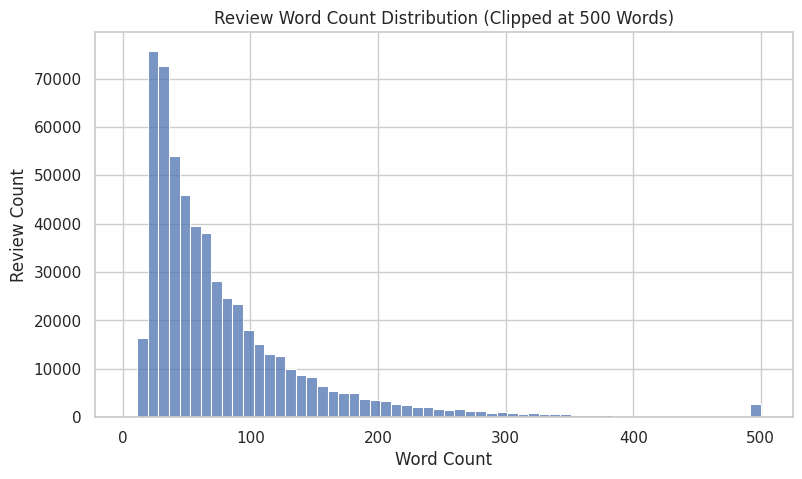

In [11]:
plt.figure(figsize=(9, 5))
sns.histplot(eda_df["text_word_count"].clip(upper=500), bins=60)
plt.title("Review Word Count Distribution (Clipped at 500 Words)")
plt.xlabel("Word Count")
plt.ylabel("Review Count")
plt.show()

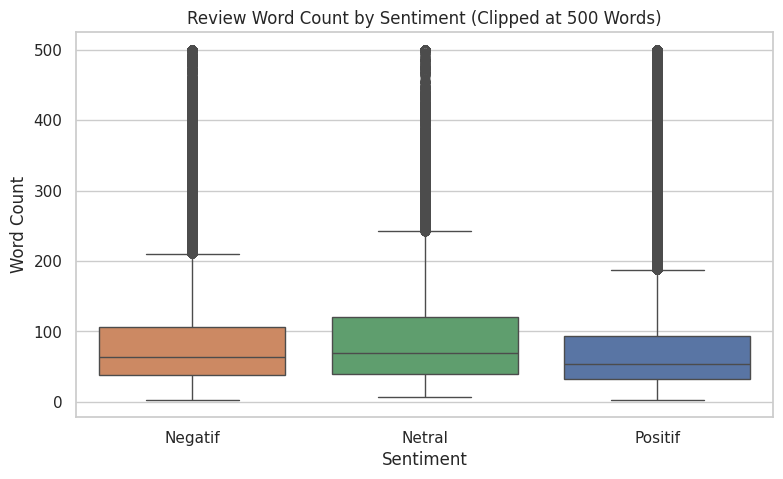

In [12]:
plot_df = eda_multiclass.copy()
plot_df["Text"] = plot_df["Text"].fillna("").astype(str)
plot_df["text_word_count"] = plot_df["Text"].str.split().str.len().clip(upper=500)

plt.figure(figsize=(9, 5))
sns.boxplot(
    data=plot_df,
    x="sentiment",
    y="text_word_count",
    order=["Negatif", "Netral", "Positif"],
    hue="sentiment",
    legend=False,
)
plt.title("Review Word Count by Sentiment (Clipped at 500 Words)")
plt.xlabel("Sentiment")
plt.ylabel("Word Count")
plt.show()

,term,count
0,br,57124
1,like,22363
2,good,17836
3,taste,15153
4,just,14971
5,product,14722
6,coffee,14718
7,great,14699
8,flavor,12976
9,tea,12455


,term,count
0,br br,22873
1,amazon com,1865
2,gluten free,1506
3,ve tried,1412
4,http www,1372
5,www amazon,1371
6,com gp,1357
7,gp product,1356
8,href http,1349
9,highly recommend,1297


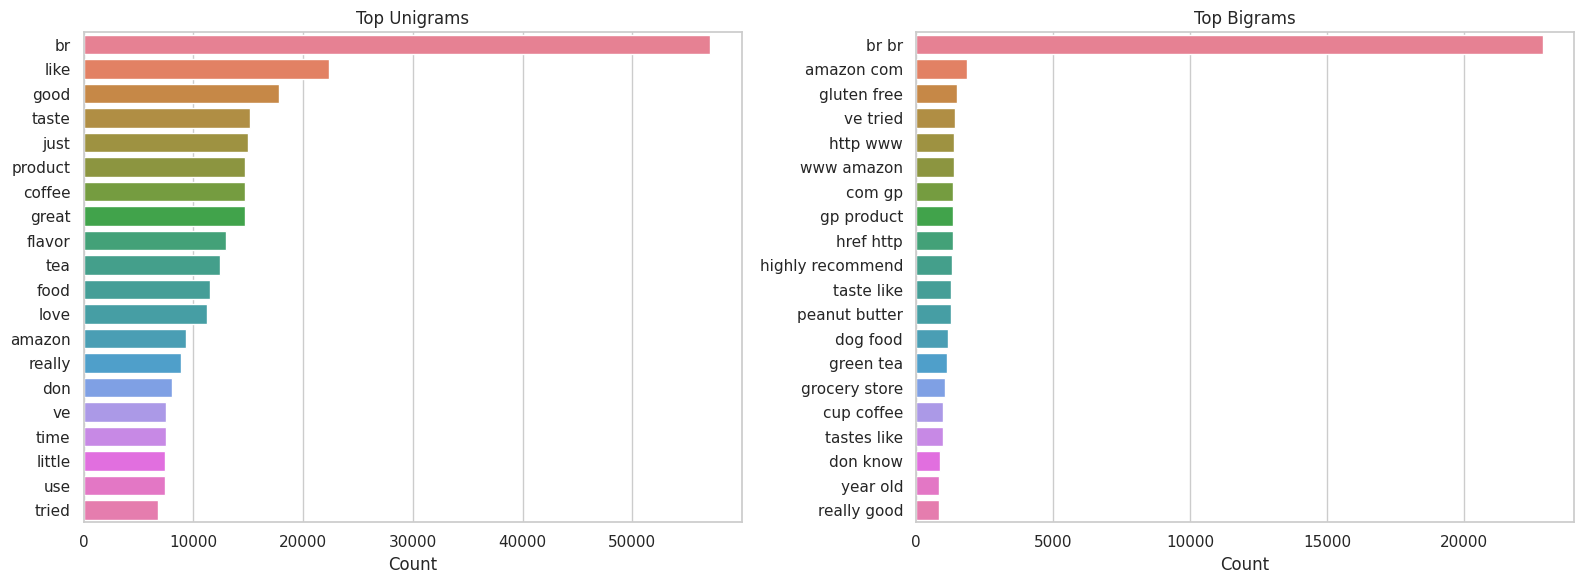

In [13]:
def top_terms(texts, ngram_range=(1, 1), top_n=20):
    vectorizer = CountVectorizer(stop_words="english", ngram_range=ngram_range, max_features=5000)
    matrix = vectorizer.fit_transform(texts)
    counts = np.asarray(matrix.sum(axis=0)).ravel()
    terms = np.array(vectorizer.get_feature_names_out())
    order = counts.argsort()[::-1][:top_n]
    return pd.DataFrame({"term": terms[order], "count": counts[order]})

sample_for_terms = eda_multiclass["Text"].fillna("").astype(str).sample(
    n=min(50000, len(eda_multiclass)), random_state=RANDOM_STATE
)

unigrams = top_terms(sample_for_terms, ngram_range=(1, 1), top_n=20)
bigrams = top_terms(sample_for_terms, ngram_range=(2, 2), top_n=20)

display(unigrams)
display(bigrams)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=unigrams, y="term", x="count", ax=axes[0], hue="term", legend=False)
axes[0].set_title("Top Unigrams")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("")

sns.barplot(data=bigrams, y="term", x="count", ax=axes[1], hue="term", legend=False)
axes[1].set_title("Top Bigrams")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## Preprocessing for Modeling

Important choices:

- keep 3-star reviews as the neutral class;
- remove exact duplicate review texts before splitting to reduce train/test leakage;
- clean HTML remnants and repeated whitespace;
- use only review `Text` as the model feature;
- use stratified train/validation/test splits because the classes are imbalanced.

In [14]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = html.unescape(str(text))
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\bbr\b", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

model_df = df[["Score", "Text"]].copy()
original_rows = len(model_df)
original_duplicate_rows = int(model_df.duplicated(subset=["Text"]).sum())
conflicting_duplicate_groups = int(model_df.groupby("Text")["Score"].nunique().gt(1).sum())

model_df = model_df.drop_duplicates(subset=["Text"], keep="first").copy()
model_df["label"] = model_df["Score"].apply(score_to_multiclass_label).astype(int)
model_df["sentiment"] = model_df["label"].map({0: "Negatif", 1: "Netral", 2: "Positif"})
model_df["clean_text"] = model_df["Text"].apply(clean_text)
model_df = model_df[model_df["clean_text"].str.len() > 0].copy()

print(f"Original rows: {original_rows:,}")
print(f"Duplicate text rows removed before split: {original_duplicate_rows:,}")
print(f"Duplicate text groups with conflicting scores: {conflicting_duplicate_groups:,}")
print(f"Rows after preprocessing: {len(model_df):,}")

model_df["sentiment"].value_counts().reindex(["Negatif", "Netral", "Positif"]).to_frame("count")

Original rows: 568,454
Duplicate text rows removed before split: 174,875
Duplicate text groups with conflicting scores: 95
Rows after preprocessing: 393,579


,count
sentiment,
Negatif,57067
Netral,29754
Positif,306758


In [15]:
label_distribution = (
    model_df["sentiment"]
    .value_counts()
    .reindex(["Negatif", "Netral", "Positif"])
    .rename_axis("sentiment")
    .reset_index(name="count")
)
label_distribution["percent"] = (label_distribution["count"] / label_distribution["count"].sum() * 100).round(2)
label_distribution

,sentiment,count,percent
0,Negatif,57067,14.50
1,Netral,29754,7.56
2,Positif,306758,77.94


## Stratified Train Validation Test Split

In [16]:
X = model_df["clean_text"]
y = model_df["label"]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train_full,
)

print(f"Train rows: {len(X_train):,}")
print(f"Validation rows: {len(X_val):,}")
print(f"Final train rows: {len(X_train_full):,}")
print(f"Test rows: {len(X_test):,}")

split_distribution = pd.DataFrame({
    "train": y_train.value_counts(normalize=True).sort_index(),
    "validation": y_val.value_counts(normalize=True).sort_index(),
    "test": y_test.value_counts(normalize=True).sort_index(),
}).rename(index={0: "Negatif", 1: "Netral", 2: "Positif"})
split_distribution.round(4)

Train rows: 251,890
Validation rows: 62,973
Final train rows: 314,863
Test rows: 78,716


,train,validation,test
label,,,
Negatif,0.1450,0.1450,0.1450
Netral,0.0756,0.0756,0.0756
Positif,0.7794,0.7794,0.7794


## Model Pipeline and Candidate Models

The model uses TF-IDF features and imbalance-aware classical text classifiers.

The main selection target is validation macro F1. Neutral-class recall is used as a tie-breaker because neutral sentiment is expected to be the hardest class.

In [17]:
def build_pipeline(model):
    return Pipeline(
        steps=[
            (
                "tfidf",
                TfidfVectorizer(
                    ngram_range=(1, 2),
                    max_features=20000,
                    min_df=3,
                    max_df=0.9,
                    sublinear_tf=True,
                    stop_words="english",
                ),
            ),
            ("model", model),
        ]
    )

candidate_models = {
    "complement_naive_bayes": ComplementNB(alpha=0.5),
    "logistic_regression_balanced_c0.5": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        C=0.5,
        random_state=RANDOM_STATE,
    ),
    "logistic_regression_balanced_c1.0": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        C=1.0,
        random_state=RANDOM_STATE,
    ),
    "logistic_regression_balanced_c2.0": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        C=2.0,
        random_state=RANDOM_STATE,
    ),
    "sgd_log_loss_balanced": SGDClassifier(
        loss="log_loss",
        penalty="l2",
        alpha=1e-5,
        max_iter=1000,
        tol=1e-3,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
}

candidate_models

{'complement_naive_bayes': ComplementNB(alpha=0.5),
 'logistic_regression_balanced_c0.5': LogisticRegression(C=0.5, class_weight='balanced', max_iter=1000,
                    random_state=42),
 'logistic_regression_balanced_c1.0': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
 'logistic_regression_balanced_c2.0': LogisticRegression(C=2.0, class_weight='balanced', max_iter=1000,
                    random_state=42),
 'sgd_log_loss_balanced': SGDClassifier(alpha=1e-05, class_weight='balanced', loss='log_loss',
               random_state=42)}

## Evaluation Helpers

In [18]:
def safe_predict_proba(estimator, X_values):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X_values)
    return None


def evaluate_model(estimator, X_values, y_values):
    y_pred = estimator.predict(X_values)
    probabilities = safe_predict_proba(estimator, X_values)

    metrics = {
        "accuracy": round(float(accuracy_score(y_values, y_pred)), 6),
        "balanced_accuracy": round(float(balanced_accuracy_score(y_values, y_pred)), 6),
        "macro_f1": round(float(f1_score(y_values, y_pred, average="macro")), 6),
        "weighted_f1": round(float(f1_score(y_values, y_pred, average="weighted")), 6),
        "confusion_matrix": confusion_matrix(y_values, y_pred, labels=LABEL_ORDER).tolist(),
        "classification_report": classification_report(
            y_values,
            y_pred,
            labels=LABEL_ORDER,
            target_names=TARGET_NAMES,
            zero_division=0,
            output_dict=True,
        ),
    }

    if probabilities is not None:
        y_binary = label_binarize(y_values, classes=LABEL_ORDER)
        metrics["roc_auc_ovr_macro"] = round(
            float(roc_auc_score(y_values, probabilities, multi_class="ovr", average="macro")), 6
        )
        metrics["roc_auc_ovr_weighted"] = round(
            float(roc_auc_score(y_values, probabilities, multi_class="ovr", average="weighted")), 6
        )
        metrics["pr_auc_macro"] = round(
            float(average_precision_score(y_binary, probabilities, average="macro")), 6
        )
        metrics["pr_auc_weighted"] = round(
            float(average_precision_score(y_binary, probabilities, average="weighted")), 6
        )

    return metrics

## Train and Compare Candidate Models

In [19]:
results = {}
best_name = None
best_pipeline = None
best_sort_key = (-1.0, -1.0, -1.0)

for name, model in candidate_models.items():
    print(f"Training: {name}")
    pipeline = build_pipeline(model)
    pipeline.fit(X_train, y_train)

    val_metrics = evaluate_model(pipeline, X_val, y_val)
    neutral_recall = val_metrics["classification_report"]["Netral"]["recall"]
    sort_key = (val_metrics["macro_f1"], neutral_recall, val_metrics["balanced_accuracy"])

    results[name] = {
        "validation_metrics": val_metrics,
    }

    print(
        f"  macro_f1={val_metrics['macro_f1']:.4f} | "
        f"balanced_accuracy={val_metrics['balanced_accuracy']:.4f} | "
        f"neutral_recall={neutral_recall:.4f}"
    )

    if sort_key > best_sort_key:
        best_name = name
        best_pipeline = pipeline
        best_sort_key = sort_key

print(f"\nSelected model: {best_name}")

Training: complement_naive_bayes


  macro_f1=0.5914 | balanced_accuracy=0.6374 | neutral_recall=0.1987
Training: logistic_regression_balanced_c0.5


  macro_f1=0.6409 | balanced_accuracy=0.7084 | neutral_recall=0.5688
Training: logistic_regression_balanced_c1.0


  macro_f1=0.6383 | balanced_accuracy=0.7028 | neutral_recall=0.5558
Training: logistic_regression_balanced_c2.0


  macro_f1=0.6349 | balanced_accuracy=0.6964 | neutral_recall=0.5358
Training: sgd_log_loss_balanced


  macro_f1=0.6702 | balanced_accuracy=0.6743 | neutral_recall=0.3770

Selected model: sgd_log_loss_balanced


In [20]:
comparison_rows = []
for name, result in results.items():
    metrics = result["validation_metrics"]
    comparison_rows.append({
        "model": name,
        "accuracy": metrics["accuracy"],
        "balanced_accuracy": metrics["balanced_accuracy"],
        "macro_f1": metrics["macro_f1"],
        "weighted_f1": metrics["weighted_f1"],
        "negative_recall": metrics["classification_report"]["Negatif"]["recall"],
        "neutral_recall": metrics["classification_report"]["Netral"]["recall"],
        "positive_recall": metrics["classification_report"]["Positif"]["recall"],
        "roc_auc_ovr_macro": metrics.get("roc_auc_ovr_macro"),
        "pr_auc_macro": metrics.get("pr_auc_macro"),
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values(
    by=["macro_f1", "neutral_recall", "balanced_accuracy"], ascending=False
)
comparison_df

,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,negative_recall,neutral_recall,positive_recall,roc_auc_ovr_macro,pr_auc_macro
4,sgd_log_loss_balanced,0.853763,0.674259,0.670215,0.854750,0.721060,0.377022,0.924696,0.908063,0.699042
1,logistic_regression_balanced_c0.5,0.790561,0.708427,0.640882,0.817345,0.733874,0.568788,0.822620,0.900813,0.684820
2,logistic_regression_balanced_c1.0,0.791339,0.702760,0.638281,0.817635,0.726207,0.555766,0.826308,0.898548,0.680036
3,logistic_regression_balanced_c2.0,0.791228,0.696409,0.634896,0.817000,0.725112,0.535812,0.828304,0.894519,0.672586
0,complement_naive_bayes,0.805647,0.637416,0.591428,0.810408,0.858942,0.198698,0.854608,0.893986,0.667162


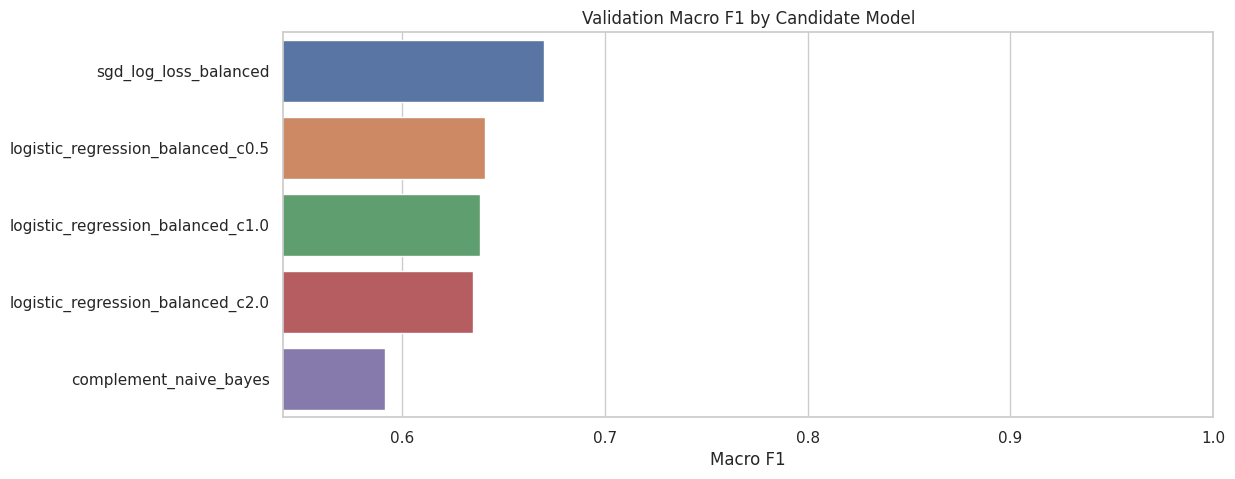

In [21]:
plt.figure(figsize=(12, 5))
sns.barplot(data=comparison_df, x="macro_f1", y="model", hue="model", legend=False)
plt.title("Validation Macro F1 by Candidate Model")
plt.xlabel("Macro F1")
plt.ylabel("")
plt.xlim(max(0, comparison_df["macro_f1"].min() - 0.05), 1.0)
plt.show()

## Final Training and Test Evaluation

In [22]:
final_pipeline = build_pipeline(candidate_models[best_name])
final_pipeline.fit(X_train_full, y_train_full)

test_metrics = evaluate_model(final_pipeline, X_test, y_test)

print(f"Final model: {best_name}")
print(f"Accuracy: {test_metrics['accuracy']:.4f}")
print(f"Balanced accuracy: {test_metrics['balanced_accuracy']:.4f}")
print(f"Macro F1: {test_metrics['macro_f1']:.4f}")
print(f"ROC-AUC OVR macro: {test_metrics.get('roc_auc_ovr_macro', np.nan):.4f}")
print(f"PR-AUC macro: {test_metrics.get('pr_auc_macro', np.nan):.4f}")

report_df = pd.DataFrame(test_metrics["classification_report"]).T
report_df

Final model: sgd_log_loss_balanced
Accuracy: 0.8546
Balanced accuracy: 0.6681
Macro F1: 0.6677
ROC-AUC OVR macro: 0.9078
PR-AUC macro: 0.6917


,precision,recall,f1-score,support
Negatif,0.701444,0.715149,0.708230,11413.000000
Netral,0.371582,0.360780,0.366101,5951.000000
Positif,0.929203,0.928446,0.928824,61352.000000
accuracy,0.854604,0.854604,0.854604,0.854604
macro avg,0.667410,0.668125,0.667719,78716.000000
weighted avg,0.854024,0.854604,0.854298,78716.000000


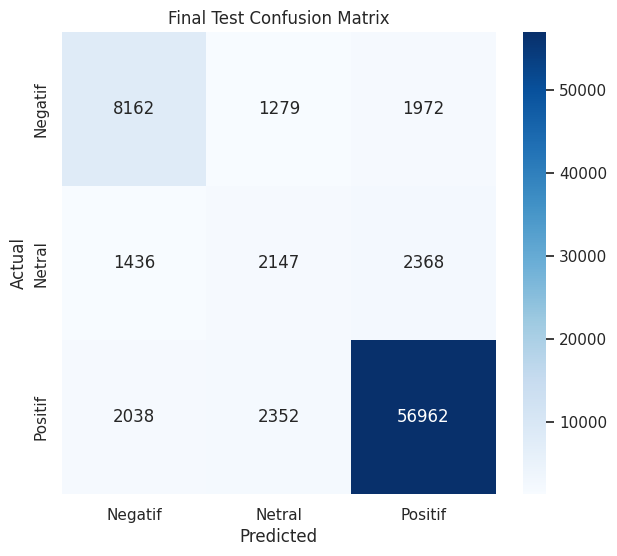

In [23]:
cm = np.array(test_metrics["confusion_matrix"])

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=TARGET_NAMES,
    yticklabels=TARGET_NAMES,
)
plt.title("Final Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Learning Curve

The learning curve uses a stratified sample of the training data to keep notebook runtime manageable. It still shows whether the selected pipeline benefits from more data and whether the gap between train and validation macro F1 suggests overfitting or underfitting.

In [24]:
if len(X_train_full) > LEARNING_CURVE_MAX_ROWS:
    X_lc, _, y_lc, _ = train_test_split(
        X_train_full,
        y_train_full,
        train_size=LEARNING_CURVE_MAX_ROWS,
        random_state=RANDOM_STATE,
        stratify=y_train_full,
    )
else:
    X_lc, y_lc = X_train_full, y_train_full

print(f"Learning curve rows: {len(X_lc):,}")

train_sizes, train_scores, validation_scores = learning_curve(
    estimator=build_pipeline(candidate_models[best_name]),
    X=X_lc,
    y=y_lc,
    train_sizes=np.linspace(0.2, 1.0, 5),
    cv=3,
    scoring="f1_macro",
    n_jobs=-1,
    shuffle=True,
    random_state=RANDOM_STATE,
)

learning_curve_df = pd.DataFrame({
    "train_size": train_sizes,
    "train_mean": train_scores.mean(axis=1),
    "train_std": train_scores.std(axis=1),
    "validation_mean": validation_scores.mean(axis=1),
    "validation_std": validation_scores.std(axis=1),
})
learning_curve_df

Learning curve rows: 60,000


,train_size,train_mean,train_std,validation_mean,validation_std
0,8000,0.999034,0.000126,0.577018,0.002757
1,16000,0.981968,0.001946,0.606891,0.002563
2,24000,0.951062,0.001774,0.615461,0.001566
3,32000,0.914755,0.001364,0.624840,0.002878
4,40000,0.879836,0.000939,0.631929,0.004883


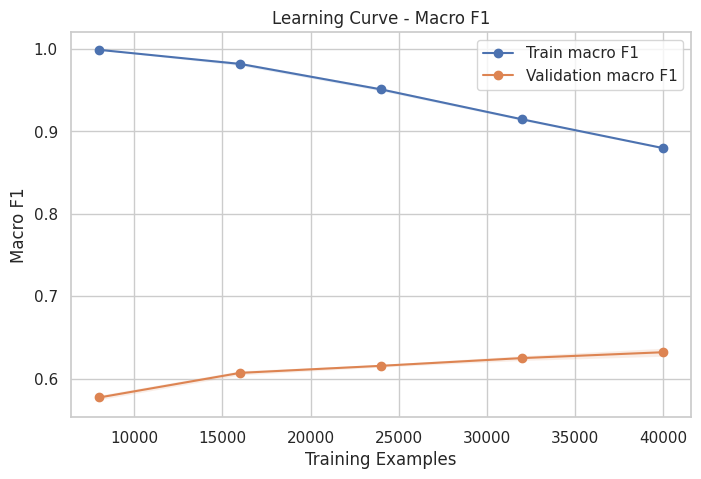

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(learning_curve_df["train_size"], learning_curve_df["train_mean"], marker="o", label="Train macro F1")
plt.fill_between(
    learning_curve_df["train_size"],
    learning_curve_df["train_mean"] - learning_curve_df["train_std"],
    learning_curve_df["train_mean"] + learning_curve_df["train_std"],
    alpha=0.15,
)
plt.plot(learning_curve_df["train_size"], learning_curve_df["validation_mean"], marker="o", label="Validation macro F1")
plt.fill_between(
    learning_curve_df["train_size"],
    learning_curve_df["validation_mean"] - learning_curve_df["validation_std"],
    learning_curve_df["validation_mean"] + learning_curve_df["validation_std"],
    alpha=0.15,
)
plt.title("Learning Curve - Macro F1")
plt.xlabel("Training Examples")
plt.ylabel("Macro F1")
plt.legend()
plt.show()

## Save Model Artifacts for Flask API

The saved artifact is one scikit-learn pipeline containing TF-IDF and the classifier. Text cleaning is done before fitting here and should also be done by the API before prediction.

In [26]:
metadata = {
    "trained_at": datetime.now(timezone.utc).isoformat(),
    "source": "main.ipynb",
    "random_state": RANDOM_STATE,
    "dataset_path": str(DATASET_PATH),
    "model_path": str(MODEL_OUTPUT_PATH),
    "task": "multiclass",
    "label_names": LABEL_NAMES,
    "dataset_summary": {
        "original_rows": int(original_rows),
        "duplicate_text_rows_removed": int(original_duplicate_rows),
        "duplicate_text_groups_with_conflicting_scores": int(conflicting_duplicate_groups),
        "rows_after_preprocessing": int(len(model_df)),
        "score_counts_after_dedup": {
            str(k): int(v) for k, v in model_df["Score"].value_counts().sort_index().items()
        },
        "label_counts": {
            str(k): int(v) for k, v in model_df["label"].value_counts().sort_index().items()
        },
        "label_percent": {
            str(k): round(float(v), 4)
            for k, v in model_df["label"].value_counts(normalize=True).sort_index().items()
        },
    },
    "split": {
        "test_size": 0.2,
        "validation_size_within_train": 0.2,
        "stratified": True,
        "train_rows_for_final_model": int(len(X_train_full)),
        "test_rows": int(len(X_test)),
    },
    "preprocessing": {
        "duplicate_text_handling": "drop_duplicates(subset=['Text'], keep='first') before split",
        "neutral_handling": "Score == 3 kept as Netral class",
        "text_cleaning": "HTML unescape, remove HTML tags, remove standalone br tokens, normalize whitespace",
    },
    "vectorizer": {
        "type": "TfidfVectorizer",
        "ngram_range": [1, 2],
        "max_features": 20000,
        "min_df": 3,
        "max_df": 0.9,
        "sublinear_tf": True,
        "stop_words": "english",
    },
    "candidate_results": results,
    "selected_model": best_name,
    "binary_decision_threshold": None,
    "test_metrics": test_metrics,
    "learning_curve": learning_curve_df.to_dict(orient="list"),
}

joblib.dump(final_pipeline, MODEL_OUTPUT_PATH)
METADATA_OUTPUT_PATH.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print(f"Saved model pipeline to: {MODEL_OUTPUT_PATH.resolve()}")
print(f"Saved metadata to: {METADATA_OUTPUT_PATH.resolve()}")

Saved model pipeline to: /home/erzeltra/daffa/college/4th-Semester/NLP/review_sentiment_analysis/sentiment_pipeline.pkl
Saved metadata to: /home/erzeltra/daffa/college/4th-Semester/NLP/review_sentiment_analysis/model_metadata.json


## Quick Inference Check

In [27]:
loaded_pipeline = joblib.load(MODEL_OUTPUT_PATH)
loaded_metadata = json.loads(METADATA_OUTPUT_PATH.read_text(encoding="utf-8"))

examples = pd.Series([
    "This product tastes great and arrived fresh.",
    "It was okay, not bad but not amazing either.",
    "This tasted awful and arrived broken.",
])
examples_clean = examples.apply(clean_text)
example_probabilities = loaded_pipeline.predict_proba(examples_clean)
example_predictions = loaded_pipeline.predict(examples_clean)

pd.DataFrame({
    "text": examples,
    "prediction": example_predictions,
    "sentiment": [LABEL_NAMES[str(label)] for label in example_predictions],
    "confidence": example_probabilities.max(axis=1).round(4),
})

,text,prediction,sentiment,confidence
0,This product tastes great and arrived fresh.,2,Positif,0.9204
1,"It was okay, not bad but not amazing either.",1,Netral,0.8550
2,This tasted awful and arrived broken.,0,Negatif,0.7814
